Connecting to drive:

In [5]:
import os
import pandas as pd

# Define your local project path ('.' means the current folder where the notebook is saved)
PROJECT_PATH = "C:\\Users\\013ri\\OneDrive\\Documents\\schoolwork\\CyberProject\\CyberSecurityMLproject"
DATASET_PATH = os.path.join(PROJECT_PATH, "datasets/training_data.csv")

# Verify the path
print(f"Project folder set to: {os.path.abspath(PROJECT_PATH)}")
print(f"Dataset path set to: {os.path.abspath(DATASET_PATH)}")

Project folder set to: C:\Users\013ri\OneDrive\Documents\schoolwork\CyberProject\CyberSecurityMLproject
Dataset path set to: C:\Users\013ri\OneDrive\Documents\schoolwork\CyberProject\CyberSecurityMLproject\datasets\training_data.csv


Generating Dataset:

Completly synthetic

In [6]:
from faker import Faker
import random
import time
import numpy as np


def generate_dataset():
    fake = Faker()
    data = []
    NUM_SAMPLES = 50000

    # --- VOCABULARY ---
    # High Value Signals
    high_exts = [".pem", ".key", ".kdbx", ".xlsx", ".pdf", ".docx", ".wallet", ".sql"]
    high_keywords = [
        "password",
        "budget",
        "secret",
        "salary",
        "invoice",
        "prod_key",
        "backup",
        "private",
        "ssh",
    ]
    high_paths = [
        "C:\\Users\\Admin\\Desktop",
        "C:\\Users\\CEO\\Documents",
        "D:\\Backups",
    ]

    # Junk Signals (Custom lists are still good for System files)
    junk_exts = [".dll", ".sys", ".tmp", ".cache", ".png", ".ico", ".dat", ".bin"]
    junk_paths = [
        "C:\\Windows\\System32",
        "C:\\Program Files",
        "C:\\Users\\Appdata\\Local\\Temp",
    ]
    print("Generating rows...")

    for _ in range(NUM_SAMPLES):
        # 1. Decide Class (95% Junk, 5% Value)
        is_target = random.choices([True, False], weights=[5, 95], k=1)[0]

        if is_target:
            # --- HIGH VALUE GENERATION ---
            # Use Custom Lists to ensure Strong Signal
            base_name = random.choice(high_keywords)
            # Add randomness so they aren't duplicates
            name = f"{base_name}_{random.randint(10,99)}"
            ext = random.choice(high_exts)
            path = random.choice(high_paths)

            # Valuable files are usually somewhat recent
            days_old = random.randint(0, 100)
            label = 1.0

        else:
            # --- JUNK GENERATION (Hybrid) ---
            # Flip a coin: 50% "Professional Noise" (Faker), 50% "System Junk" (Custom)

            if random.random() > 0.5:
                # Option A: Faker (Realism)
                # Generates: 'marketing_plan.pdf', 'logo.png'
                name = fake.file_name(category=None, extension="")
                ext = "." + fake.file_extension()
                # Faker paths look like: /usr/local/bin... we need to fake Windows paths
                path = f"C:\\Users\\{fake.user_name()}\\Downloads"

            else:
                # Option B: System Junk
                name = f"sys_{random.randint(1000,9999)}"
                ext = random.choice(junk_exts)
                path = random.choice(junk_paths)

            days_old = random.randint(0, 2000)
            label = 0.0

        # 2. Shared Metadata Logic
        current_time = time.time()
        mod_time = int(current_time - (days_old * 24 * 3600))

        # Calculate size based on extension
        if ext in [".pem", ".key", ".txt"]:
            size = random.randint(100, 4000)  # Small keys
        else:
            size = random.randint(10000, 50 * 1024 * 1024)  # Big binaries/docs

        data.append(
            {
                "filename": name + ext,
                "path": path,
                "extension": ext,
                "size_bytes": size,
                "mod_time_unix": mod_time,
                "label": label,
            }
        )

    return pd.DataFrame(data)

M57-patent dataset

In [3]:
import xml.etree.ElementTree as ET
import pandas as pd
import os

def xml_to_raw_csv(xml_files, output_csv="../datasets/m57_raw_dump.csv"):
    all_rows = []
    
    for xml_file in xml_files:
        if not os.path.exists(xml_file):
            print(f"⚠️ Skipping missing file: {xml_file}")
            continue
            
        print(f"Parsing {xml_file}...")
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
            
            source_user = os.path.basename(xml_file).split('-')[0]

            for file_obj in root.findall(".//fileobject"):
                # --- 1. OPTIMIZATION: Filter Directories Immediately ---
                ntype = file_obj.find("name_type")
                
                # 'd' = Directory. We skip these to save massive space.
                if ntype is not None and ntype.text == 'd':
                    continue

                row = {}
                row['source_user'] = source_user
                row['type'] = ntype.text if ntype is not None else "unknown"

                # --- 2. Extract Data ---
                
                # Filename (Raw)
                fname_tag = file_obj.find("filename")
                if fname_tag is not None:
                    row['raw_path'] = fname_tag.text
                else:
                    continue # Skip objects with no name

                # File Size
                fsize = file_obj.find("filesize")
                row['size'] = int(fsize.text) if fsize is not None else 0

                # Timestamps
                mtime = file_obj.find("mtime")
                row['mtime_iso'] = mtime.text if mtime is not None else None
                
                # Flags ('unalloc' = 1 means DELETED file)
                unalloc = file_obj.find("unalloc")
                row['is_deleted'] = 1 if (unalloc is not None and unalloc.text == '1') else 0

                all_rows.append(row)
                
        except Exception as e:
            print(f"❌ Error parsing {xml_file}: {e}")

    # Convert to DataFrame
    df = pd.DataFrame(all_rows)
    
    # Save raw output with BOM for VS Code compatibility
    df.to_csv(output_csv, index=False, encoding='utf-8-sig')
    print(f"\n✅ Success! Saved {len(df)} file rows (no directories) to '{output_csv}'")
    return df

# --- CONFIGURATION ---
target_files = [
    "../datasets/charlie-2009-12-11.xml",
    "../datasets/jo-2009-12-11-002.xml",
    "../datasets/pat-2009-12-11.xml",
    "../datasets/terry-2009-12-11-002.xml"
]

# RUN IT
xml_to_raw_csv(target_files)

Parsing ../datasets/charlie-2009-12-11.xml...
Parsing ../datasets/jo-2009-12-11-002.xml...
Parsing ../datasets/pat-2009-12-11.xml...
Parsing ../datasets/terry-2009-12-11-002.xml...

✅ Success! Saved 207461 file rows (no directories) to '../datasets/m57_raw_dump.csv'


,source_user,type,raw_path,size,mtime_iso,is_deleted
0,charlie,r,$AttrDef,2560,2009-11-08T16:58:56Z,0
1,charlie,r,$AVG/$CHJW/23327068-982b-4c1f-a43a-fb5e73e62883,384,2009-11-10T00:45:33Z,0
2,charlie,r,$AVG/$CHJW/3d1d098e-5278-4184-b6c1-681170b37870,328,2009-11-10T00:45:33Z,0
3,charlie,r,$AVG/$CHJW/avgcchff.dat,934072,2009-12-09T10:54:18Z,0
4,charlie,r,$AVG/$CHJW/avgcchfi.dat,118600,2009-12-11T00:53:57Z,0
...,...,...,...,...,...,...
207456,terry,-,$OrphanFiles/package_101_for_kb976098_bf~31bf3...,8461,2009-10-30T12:54:05Z,1
207457,terry,-,$OrphanFiles/package_100_for_kb976098~31bf3856...,11964,2009-10-30T10:41:08Z,1
207458,terry,-,$OrphanFiles/package_100_for_kb976098~31bf3856...,9339,2009-10-30T11:38:56Z,1
207459,terry,-,$OrphanFiles/package_100_for_kb976098_bf~31bf3...,1978,2009-10-30T10:50:11Z,1


In [7]:
import pandas as pd
# Use the python engine which is more robust to bad lines
df = pd.read_csv("../datasets/m57_raw_dump.csv", nrows=10, encoding_errors='replace')
df

,source_user,type,raw_path,size,mtime_iso,is_deleted
0,charlie,r,$AttrDef,2560,2009-11-08T16:58:56Z,0
1,charlie,r,$AVG/$CHJW/23327068-982b-4c1f-a43a-fb5e73e62883,384,2009-11-10T00:45:33Z,0
2,charlie,r,$AVG/$CHJW/3d1d098e-5278-4184-b6c1-681170b37870,328,2009-11-10T00:45:33Z,0
3,charlie,r,$AVG/$CHJW/avgcchff.dat,934072,2009-12-09T10:54:18Z,0
4,charlie,r,$AVG/$CHJW/avgcchfi.dat,118600,2009-12-11T00:53:57Z,0
5,charlie,r,$AVG/$CHJW/avgcchmf.dat,1215060,2009-12-09T10:54:18Z,0
6,charlie,r,$AVG/$CHJW/avgcchmi.dat,99136,2009-12-11T00:53:57Z,0
7,charlie,r,$AVG/$CHJW/avgcchmi.dat,0,NaN,1
8,charlie,r,$AVG/$VAULT/vvfolder.idx,909,2009-12-11T00:53:48Z,0
9,charlie,r,$AVG/$VAULT/V_00000001.fil,730,2009-11-11T22:09:31Z,0


In [10]:
import xml.etree.ElementTree as ET
import pandas as pd
import datetime
import random
import time

def parse_and_modernize_dfxml(dfxml_path):
    print(f"Processing {dfxml_path}...")
    tree = ET.parse(dfxml_path)
    root = tree.getroot()
    
    rows = []
    
    # Calculate time shift (approx 15 years in seconds)
    # We want 2009 files to look like they are from 2024
    TIME_SHIFT = 15 * 365 * 24 * 3600 
    
    for file_obj in root.findall(".//fileobject"):
        try:
            # 1. FILTER: Skip Deleted/Unallocated files
            # These don't exist in a live scan
            if file_obj.find("unalloc") is not None and file_obj.find("unalloc").text == '1':
                continue
                
            # 2. FILTER: Skip Directories
            name_type = file_obj.find("name_type")
            if name_type is not None and name_type.text != "r": 
                continue

            # 3. Get Filename
            filename_tag = file_obj.find("filename")
            if filename_tag is None or not filename_tag.text:
                continue
            
            raw_path = filename_tag.text # e.g. "Documents and Settings/Charlie/My Documents/resume.doc"
            
            # --- MODERNIZATION LOGIC ---
            
            # A. Fix Separators and Drive Letter
            win_path = "C:\\" + raw_path.replace("/", "\\")
            
            # B. Fix Legacy Paths (XP -> Windows 10/11)
            if "Documents and Settings" in win_path:
                win_path = win_path.replace("Documents and Settings", "Users")
            
            # C. Inject Modern Cloud Context (10% chance for user docs)
            # Simulates files being in OneDrive instead of just Documents
            if "Users" in win_path and "Documents" in win_path and random.random() < 0.10:
                win_path = win_path.replace("Documents", "OneDrive\\Documents")

            # Split into path and filename for the model
            if "\\" in win_path:
                path_dir, name = win_path.rsplit("\\", 1)
            else:
                path_dir = "C:\\"
                name = win_path

            # D. Modernize Extensions (doc -> docx, xls -> xlsx)
            if name.endswith(".doc") and random.random() > 0.2: name += "x"
            if name.endswith(".xls") and random.random() > 0.2: name += "x"
            if name.endswith(".ppt") and random.random() > 0.2: name += "x"
            
            # Extract new extension
            ext = "." + name.rsplit(".", 1)[-1].lower() if "." in name else ""

            # 4. Get Size
            filesize_tag = file_obj.find("filesize")
            size = int(filesize_tag.text) if filesize_tag is not None else 0
            
            # 5. Get and Shift Time
            mtime_tag = file_obj.find("mtime")
            if mtime_tag is not None:
                # Parse ISO format
                dt = datetime.datetime.fromisoformat(mtime_tag.text.replace("Z", "+00:00"))
                # Shift forward by 15 years
                mod_time_unix = int(dt.timestamp()) + TIME_SHIFT
            else:
                mod_time_unix = time.time() - random.randint(0, 100000)

            rows.append({
                "filename": name,      # Modernized Name
                "path": path_dir,      # Modernized Path
                "extension": ext,      # Modernized Ext
                "size_bytes": size,
                "mod_time_unix": mod_time_unix, # Modernized Time
                # We will apply the Labeling Logic (IT vs HR) later
            })
            
        except Exception as e:
            continue
            
    return pd.DataFrame(rows)

# --- USAGE ---
df = parse_and_modernize_dfxml("../datasets/charlie-2009-12-11.xml")
print(df.head())
print(df[df['path'].str.contains("OneDrive")].head()) # Verify cloud injection
df.to_csv("../datasets/charlie-2009-12-11-modernized.csv", index=False)

Processing ../datasets/charlie-2009-12-11.xml...
                               filename           path extension  size_bytes  \
0                              $AttrDef             C:                  2560   
1  23327068-982b-4c1f-a43a-fb5e73e62883  C:\$AVG\$CHJW                   384   
2  3d1d098e-5278-4184-b6c1-681170b37870  C:\$AVG\$CHJW                   328   
3                          avgcchff.dat  C:\$AVG\$CHJW      .dat      934072   
4                          avgcchfi.dat  C:\$AVG\$CHJW      .dat      118600   

   mod_time_unix  
0   1.730740e+09  
1   1.730854e+09  
2   1.730854e+09  
3   1.733396e+09  
4   1.733533e+09  
                              filename  \
1252               Sample Pictures.lnk   
2132                       desktop.ini   
2152                        Sunset.jpg   
4643  FoxitReader31_enu_Setup_1030.exe   

                                                   path extension  size_bytes  \
1252  C:\Users\Administrator\My OneDrive\Documents\M...      .ln

In [ ]:
#df[0:50]
df[df['path'].str.contains("OneDrive")]


,filename,path,extension,size_bytes,mod_time_unix
1252,Sample Pictures.lnk,C:\Users\Administrator\My OneDrive\Documents\M...,.lnk,668,1.730770e+09
2129,desktop.ini,C:\Users\All Users\OneDrive\Documents,.ini,62,1.730740e+09
2150,Blue hills.jpg,C:\Users\All Users\OneDrive\Documents\My Pictu...,.jpg,28521,1.681214e+09
4637,astronaut1.jpg,C:\Users\Charlie\My OneDrive\Documents,.jpg,722717,1.732139e+09
4639,060402_rpts_torn.csv,C:\Users\Charlie\My OneDrive\Documents\Downloads,.csv,9982,1.731794e+09
4642,cygnusfe.zip,C:\Users\Charlie\My OneDrive\Documents\Downloads,.zip,290828,1.732140e+09
4663,GB2009000189_11092009.xml.gz,C:\Users\Charlie\My OneDrive\Documents\Quantum...,.gz,3442,1.733524e+09


Saving/loading Dataset:

In [7]:
# Check if dataset exists
if not os.path.exists(DATASET_PATH):
    print("⚠️ Dataset not found. Generating new data (This takes time)...")

    df = generate_dataset()

    # --- SAVE TO DRIVE ---
    print(f"Saving to {DATASET_PATH}...")
    df.to_csv(DATASET_PATH, index=False)
    print("✅ Saved!")

Pre-processing the dataset:

In [8]:
import time
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import HashingVectorizer
from scipy.sparse import hstack

df = pd.read_csv(DATASET_PATH)

valuable_exts = [".pem", ".key", ".kdbx", ".xlsx", ".pdf", ".docx", ".wallet", ".sql"]

# todo: recency score - new files get close to 1, year old files are close to 0
df["recency_score"] = 1 / ((time.time() - df["mod_time_unix"]) / (24 * 3600) + 1)
df["size_logged"] = np.log1p(df["size_bytes"])

# todo: change to more nuanced scoring/hashing
df["valuable_ext"] = (
    df["extension"]
    .isin(valuable_exts)
    .astype(int)
)

# Initialize HashingVectorizer
hashing_vectorizer = HashingVectorizer(
    n_features=1024,
    analyzer="char",
    norm=None,
    alternate_sign=False,
    ngram_range=(3, 3),
)

# Apply feature hashing to the 'filename' column
filename_vectors = hashing_vectorizer.fit_transform(df["filename"])
path_vectors = hashing_vectorizer.fit_transform(df["path"])

# # Dropping original columns after they've been used for feature creation
# df.drop(
#     ["filename", "path", "extension", "size_bytes", "mod_time_unix"],
#     axis=1,
#     inplace=True,
# )

numerical_features = df[["recency_score", "size_logged", "valuable_ext"]].values
X = hstack([numerical_features, filename_vectors, path_vectors])
y = df["label"].values

In [9]:
df

,filename,path,extension,size_bytes,mod_time_unix,label,recency_score,size_logged,valuable_ext
0,paper.js,C:\Users\ubutler\Downloads,.js,25770189,1621424970,0.0,0.000594,17.064729,0
1,sys_3758.tmp,C:\Program Files,.tmp,8588014,1730202570,0.0,0.002351,15.965878,0
2,sys_7886.sys,C:\Program Files,.sys,28509871,1720525770,0.0,0.001861,17.165761,0
3,sys_7833.tmp,C:\Program Files,.tmp,26387708,1749296970,0.0,0.004894,17.088409,0
4,stage.js,C:\Users\shahpaul\Downloads,.js,6673146,1706788170,0.0,0.001436,15.713602,0
...,...,...,...,...,...,...,...,...,...
49995,invoice_54.pem,C:\Users\CEO\Documents,.pem,1534,1764071375,1.0,0.029991,7.336286,1
49996,ssh_17.xlsx,C:\Users\Admin\Desktop,.xlsx,16812673,1759232975,1.0,0.011193,16.637644,1
49997,secret_47.pdf,D:\Backups,.pdf,23035718,1762343375,1.0,0.018746,16.952557,1
49998,secret_11.xlsx,C:\Users\CEO\Documents,.xlsx,9933757,1758628175,1.0,0.010380,16.111449,1


In [10]:
# Convert the first 5 rows to a dense array
X_sample_dense = X.toarray()

# To make it more readable, let's put it into a DataFrame, although this is only for display purposes
# as X itself is a sparse matrix.
num_numerical_features = numerical_features.shape[1]
num_filename_features = filename_vectors.shape[1]
num_path_features = path_vectors.shape[1]

# Create column names for better readability
column_names = (
    ["recency_score", "size_logged", "valuable_ext"]
    + [f"filename_hash_{i}" for i in range(num_filename_features)]
    + [f"path_hash_{i}" for i in range(num_path_features)]
)

# Display the sample as a DataFrame
X_sample_df = pd.DataFrame(X_sample_dense, columns=column_names)
display(X_sample_df)

,recency_score,size_logged,valuable_ext,filename_hash_0,filename_hash_1,filename_hash_2,filename_hash_3,filename_hash_4,filename_hash_5,filename_hash_6,...,path_hash_1014,path_hash_1015,path_hash_1016,path_hash_1017,path_hash_1018,path_hash_1019,path_hash_1020,path_hash_1021,path_hash_1022,path_hash_1023
0,0.000594,17.064729,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.002351,15.965878,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.001861,17.165761,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.004894,17.088409,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.001436,15.713602,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.029991,7.336286,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49996,0.011193,16.637644,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49997,0.018746,16.952557,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
49998,0.010380,16.111449,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Training:

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Split Data
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

# 2. Train Model
# Using 'lbfgs' solver is standard. max_iter increased to ensure convergence.
model = LogisticRegression(solver="lbfgs", max_iter=1000)
model.fit(X_train, y_train)

# 3. Evaluate
y_pred = model.predict(X_test)
y_scores = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9511
         1.0       1.00      1.00      1.00       489

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [12]:
results = pd.DataFrame({
    'filepath': df.loc[idx_test]['path'].values,
    'filename': df.loc[idx_test]['filename'].values,
    'extension': df.loc[idx_test]['extension'].values,
    'size_bytes': df.loc[idx_test]['size_bytes'].values,
    'mod_time_unix': df.loc[idx_test]['mod_time_unix'].values,
    'actual_label': y_test,
    'model_score': y_scores
})

# Sort and slice the results
sorted_results = results.sort_values(by='model_score', ascending=False)
sorted_results[460:500]

,filepath,filename,extension,size_bytes,mod_time_unix,actual_label,model_score
7535,D:\Backups,backup_57.xlsx,.xlsx,19824450,1764157771,1.0,0.997042
4980,D:\Backups,backup_46.pdf,.pdf,10195859,1765280971,1.0,0.997003
9182,D:\Backups,secret_14.pdf,.pdf,50418410,1763812174,1.0,0.996960
8887,D:\Backups,invoice_44.sql,.sql,51147698,1764762572,1.0,0.996791
8155,D:\Backups,invoice_62.docx,.docx,33872129,1759492172,1.0,0.996666
2302,D:\Backups,backup_18.docx,.docx,8682864,1760701772,1.0,0.996622
2433,D:\Backups,private_47.sql,.sql,41916307,1765972172,1.0,0.996618
1563,D:\Backups,salary_94.xlsx,.xlsx,49136331,1764589772,1.0,0.996588
9702,D:\Backups,invoice_14.sql,.sql,45716991,1759232972,1.0,0.996580
7759,D:\Backups,salary_73.kdbx,.kdbx,32574238,1764416973,1.0,0.996538


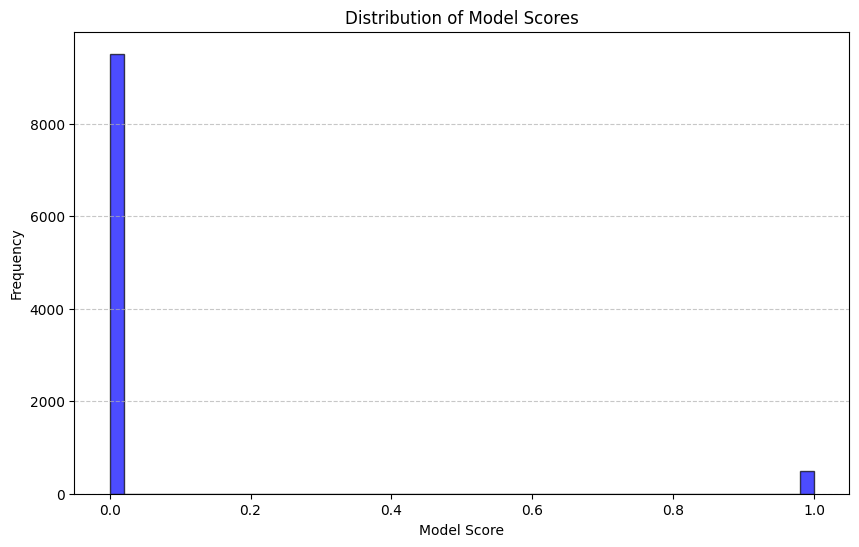

In [13]:
import matplotlib.pyplot as plt

# Plot the distribution of model scores
plt.figure(figsize=(10, 6))
plt.hist(sorted_results['model_score'], bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Model Scores')
plt.xlabel('Model Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Exporting weights:

In [ ]:
import os

def export_model_to_cpp(model, output_path="include/Weights.h"):
    """
    Exports sklearn LogisticRegression weights to a C++ header file.
    """
    # Extract Parameters
    bias = model.intercept_[0]
    weights = model.coef_.flatten()

    # Format the Content
    cpp_content =f"""
#pragma once
// AUTOMATICALLY GENERATED FILE 
// Weights Count: {len(weights)}

#include <vector>
#include <unordered_set>
#include <string>

const double MODEL_BIAS = {bias:.10f};

const std::vector<double> MODEL_WEIGHTS = {{
{', '.join([f'{w:.10f}' for w in weights])}}};

const std::unordered_set<std::wstring> HIGH_VAL_EXTS = {{
    {', '.join([f'L"{ext}"' for ext in valuable_exts])}}};
"""

    # 3. Ensure Directory Exists and Write
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with open(output_path, "w") as f:
        f.write(cpp_content)

    print(f"exported weights to: {os.path.abspath(output_path)}")
    print(f"Bias: {bias:.6f}")
    print(f"Num of weights: {len(weights)}")


export_model_to_cpp(model, output_path="../include/ModelWeights.h")

exported weights to: c:\Users\013ri\OneDrive\Documents\schoolwork\CyberProject\CyberSecurityMLproject\include\ModelWeights.h
Bias: 0.089570
Num of weights: 2051
